In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("titanic_toy.csv")

In [9]:
df.sample(5)

,Age,Fare,Family,Survived
323,22.0,29.0000,2,1
810,26.0,7.8875,0,0
440,45.0,26.2500,2,1
50,7.0,39.6875,5,0
423,28.0,14.4000,2,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [13]:
df.shape

(891, 4)

In [14]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer 
from sklearn.compose import ColumnTransformer

In [16]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [17]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.2,random_state=2)

In [19]:
x_train.shape,x_test.shape

((712, 3), (179, 3))

In [20]:
x_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [22]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()

mean_fare = x_train['Fare'].mean()
median_fare = x_train['Fare'].median()

In [23]:
x_train['Age_median'] = x_train['Age'].fillna(median_age)
x_train['Age_mean'] = x_train['Age'].fillna(mean_age)

x_train['Fare_median'] = x_train['Fare'].fillna(median_fare)
x_train['Fare_mean'] = x_train['Fare'].fillna(mean_fare)

In [24]:
x_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
194,44.0,NaN,0,44.00,44.000000,14.4583,32.617597
357,38.0,13.0,0,38.00,38.000000,13.0000,13.000000
148,36.5,26.0,2,36.50,36.500000,26.0000,26.000000
277,NaN,0.0,0,28.75,29.785904,0.0000,0.000000
385,18.0,73.5,0,18.00,18.000000,73.5000,73.500000


In [25]:
print('Original Age variable variance: ', x_train['Age'].var())
print('Age Variance after median imputation: ', x_train['Age_median'].var())
print('Age Variance after mean imputation: ', x_train['Age_mean'].var())

print('Original Fare variable variance: ', x_train['Fare'].var())
print('Fare Variance after median imputation: ', x_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', x_train['Fare_mean'].var())

Original Age variable variance:  204.3495133904614
Age Variance after median imputation:  161.9895663346054
Age Variance after mean imputation:  161.81262452718673
Original Fare variable variance:  2448.197913706318
Fare Variance after median imputation:  2340.0910219753637
Fare Variance after mean imputation:  2324.2385256705547


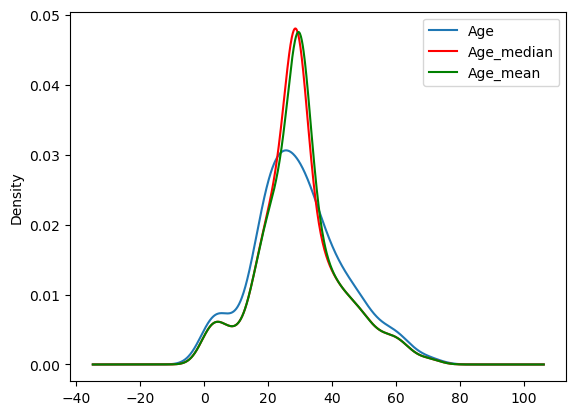

In [27]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Age'].plot(kind='kde', ax=ax)#kde=kernel dnsity estimation

# variable imputed with the median
x_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

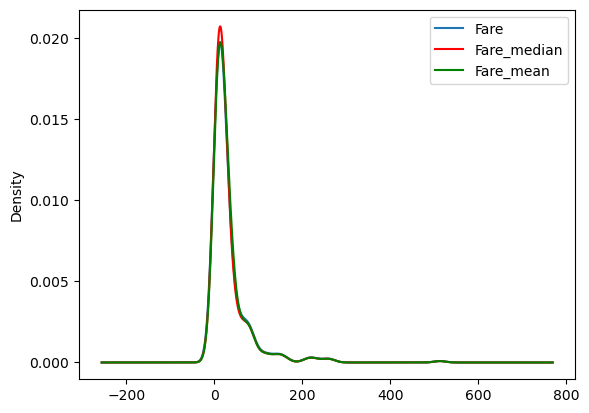

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
x_train['Fare'].plot(kind='kde', ax=ax)

# variable imputed with the median
x_train['Fare_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
x_train['Fare_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

In [32]:
x_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858859,66.665205
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.476305,16.385048
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,53.553455,55.023037
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,51.358000,52.788341
Fare_median,64.858859,2448.197914,16.476305,53.553455,51.358000,2340.091022,2324.238526
Fare_mean,66.665205,2448.197914,16.385048,55.023037,52.788341,2324.238526,2324.238526


In [33]:
x_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.087356,0.090156
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,0.205942,0.205499
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.086982,0.089673
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.083461,0.086078
Fare_median,0.087356,1.000000,0.205942,0.086982,0.083461,1.000000,0.996607
Fare_mean,0.090156,1.000000,0.205499,0.089673,0.086078,0.996607,1.000000


<Axes: >

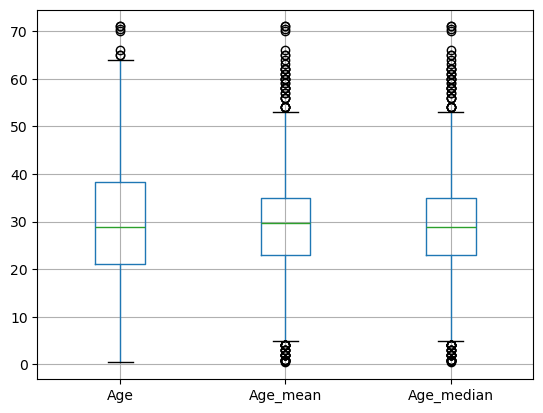

In [36]:
x_train[['Age','Age_mean','Age_median']].boxplot()

<Axes: >

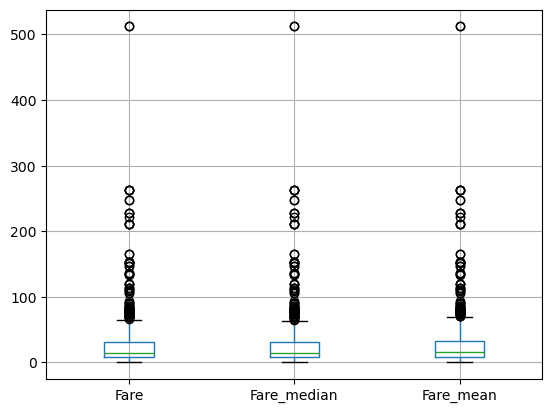

In [37]:
x_train[['Fare', 'Fare_median', 'Fare_mean']].boxplot()

Using Sklearn

In [39]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [40]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [42]:
trf.fit(x_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [43]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [44]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [49]:
print(type(x_train))

<class 'numpy.ndarray'>


In [50]:
x_train

array([[ 40.        ,  27.7208    ,   0.        , ...,  40.        ,
         27.7208    ,  27.7208    ],
       [  4.        ,  16.7       ,   2.        , ...,   4.        ,
         16.7       ,  16.7       ],
       [ 47.        ,   9.        ,   0.        , ...,  47.        ,
          9.        ,   9.        ],
       ...,
       [ 71.        ,  49.5042    ,   0.        , ...,  71.        ,
         49.5042    ,  49.5042    ],
       [ 28.75      , 221.7792    ,   0.        , ...,  29.78590426,
        221.7792    , 221.7792    ],
       [ 28.75      ,  25.925     ,   0.        , ...,  29.78590426,
         25.925     ,  25.925     ]], shape=(712, 7))

In [54]:
x_train = pd.DataFrame(x_train,columns=['Age','Fare','Family','Age_median','Age_mean','Fare_median','Fare_mean'])
x_test = pd.DataFrame(x_test,columns=['Age','Fare','Family','Age_median','Age_mean','Fare_median','Fare_mean'])

In [55]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)